## DS 6050 Final Project

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, Input

In [2]:
# get data path
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

100%|██████████| 612M/612M [00:11<00:00, 55.9MB/s] 

Extracting files...


Path to dataset files: /Users/NovaMist/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1


In [ ]:
# see list of data files
print(os.listdir(path))

['Test', 'Test.csv', 'Meta', 'Train', 'Meta.csv', 'Train.csv']


In [13]:
# Load in train and test csv
train_df = pd.read_csv(os.path.join(path, "Train.csv"))
test_df = pd.read_csv(os.path.join(path, "Test.csv"))

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print(train_df.head())
print( f"\nSuccessfully loaded metadata for {len(train_df)} images.")

Train rows: 39209 Test rows: 12630
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

Successfully loaded metadata for 39209 images.


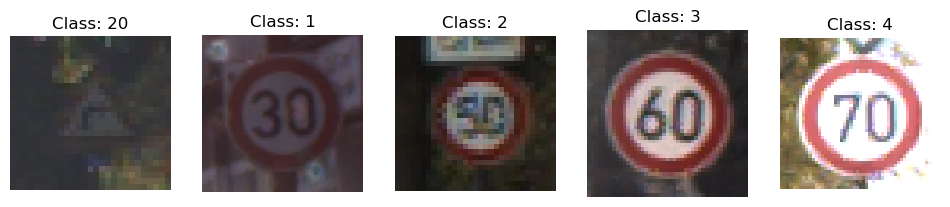

In [ ]:
# quickly look at a few images with annotation
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img_relative_path = train_df.iloc[i * 2000]['Path']
    img_full_path = os.path.join(path, img_relative_path)
    
    img = Image.open(img_full_path)
    plt.imshow(img)
    plt.title(f"Class: {train_df.iloc[i * 2000]['ClassId']}")
    plt.axis('off')
plt.show()

In [18]:
# Build tf.data pipeline
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, training=True):
    paths = [os.path.join(path, p) for p in df["Path"].values]
    labels = df["ClassId"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
test_ds = make_dataset(test_df, training=False)

In [19]:
# build a model

model = models.Sequential([
    Input(shape=(32, 32, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Quick training run ( will set epochs higher later)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4438 - loss: 2.0355 - val_accuracy: 0.5595 - val_loss: 1.5686
Epoch 2/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7855 - loss: 0.6634 - val_accuracy: 0.7861 - val_loss: 0.8077
Epoch 3/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9130 - loss: 0.2811 - val_accuracy: 0.8354 - val_loss: 0.6163


In [21]:
# Prediction demo
x_batch, y_batch = next(iter(test_ds))
probs = model.predict(x_batch, verbose=0)
preds = tf.argmax(probs, axis=1)

print("Predicted:", preds[:10].numpy())
print("Actual:   ", y_batch[:10].numpy())

Predicted: [16  1 38 33 11 38 18 12 25 35]
Actual:    [16  1 38 33 11 38 18 12 25 35]


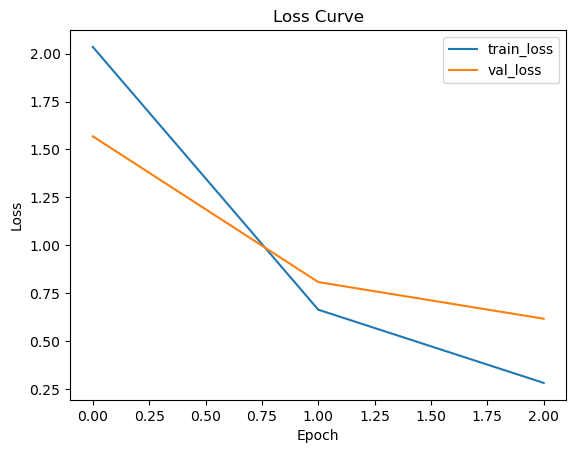

In [22]:
# plotting Loss curve
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()